In [1]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [2]:
# PM25
df = pd.read_csv('training_data.csv')
df.columns


Index(['date', 'temperature_2m_max', 'precipitation_sum',
       'precipitation_hours', 'uv_index_max', 'wind_speed_10m_max',
       'shortwave_radiation_sum', 'NO2', 'PM25', 'NO2_r7', 'PM25_r7', 'NO2_l1',
       'NO2_l3', 'NO2_l7', 'PM25_l1', 'PM25_l3', 'PM25_l7', 'wind_r3'],
      dtype='str')

In [3]:
df.set_index('date',inplace=True)


In [4]:
# initial model
split_idx = int(len(df) * 0.8)
X=df
X.drop(['NO2_l7','NO2_r7','PM25'],axis=1)
Y=df['PM25']
X_train,X_test = X[:split_idx],X[split_idx:]
Y_train,Y_test = Y[:split_idx], Y[split_idx:]


In [5]:
# baseline model
SEED=42

model = RandomForestRegressor(n_estimators = 200, max_depth=10, random_state = SEED)

model.fit(X_train,Y_train)

preds = model.predict(X_test)


In [6]:
rmse = np.sqrt(mean_squared_error(Y_test, preds))
mae  = mean_absolute_error(Y_test, preds)

print("RMSE:", rmse)
print("MAE:", mae)
print(Y_test.describe())


RMSE: 0.09936854128136298
MAE: 0.0551882319359927
count    72.000000
mean      8.900137
std       3.805329
min       2.315833
25%       5.858308
50%       8.377292
75%      11.788339
max      17.413144
Name: PM25, dtype: float64


In [ ]:
# only 0.099 RMSE -> less than 9% error
# 0.055 MAE -> on average, prediction only differs from mean by 0.055


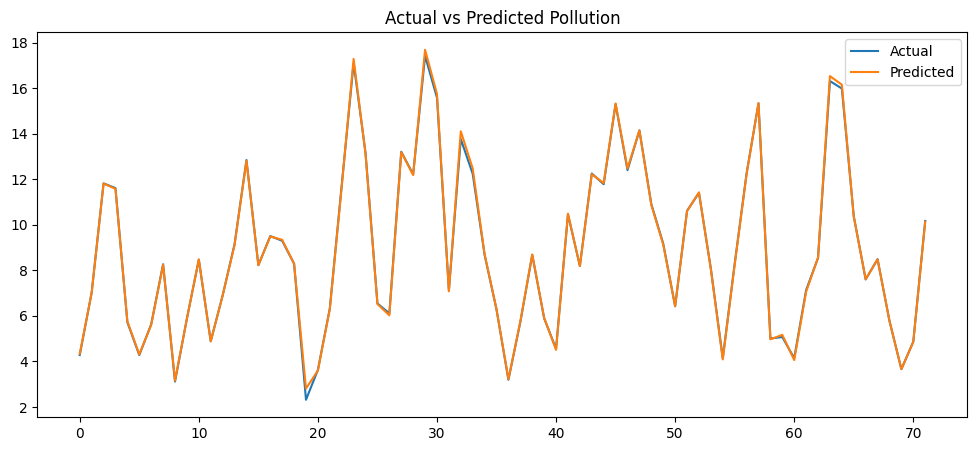

In [9]:
plt.figure(figsize=(12,5))
plt.plot(Y_test.values, label="Actual")
plt.plot(preds, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Pollution")
plt.show()


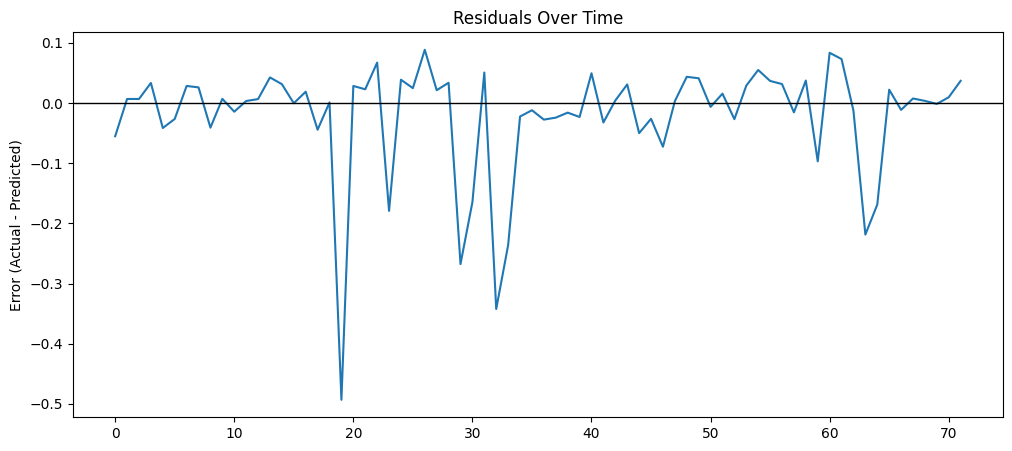

In [12]:
residuals = Y_test - preds
plt.figure(figsize=(12,5))
plt.plot(residuals.values)
plt.axhline(0, color='black', linewidth=1)
plt.title("Residuals Over Time")
plt.ylabel("Error (Actual - Predicted)")
plt.show()


In [13]:
baseline = Y_test.shift(1)

rmse_baseline = np.sqrt(mean_squared_error(Y_test[1:], baseline[1:]))

print("Baseline RMSE:", rmse_baseline)
print("Model RMSE:", rmse)


Baseline RMSE: 3.8258800650636178
Model RMSE: 0.09936854128136298
